In [8]:
## IMPORTS 
import os
import sys 
LOCSCALE_2_SCRIPTS_PATH = "/home/abharadwaj1/papers/publications/2025_LocScale_2"
PLOT_DATA_STORE_PATH = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data"
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import pickle
import pandas as pd
import seaborn as sns
from scripts.utils.plot_utils import pretty_plot_radial_profile, temporary_rcparams, configure_plot_scaling
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist

random.seed(42)
np.random.seed(42)

# Figure 6 h 

In [9]:
# recall_curves_0665 = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_0665/recall_curves_EMD_0665_new_with_diffmask.csv"

# recall_curves_data_0665 = pd.read_csv(recall_curves_0665)
# recall_curves_data_0665.head()

In [10]:
# x_array = recall_curves_data_0665['Threshold']
# feature_enhanced_recall = recall_curves_data_0665['Feature Enhanced']
# deepemhancer_recall = recall_curves_data_0665['DeepEMhancer']
# emready_recall = recall_curves_data_0665['EMready']

# # convert to long format
# recall_data_0665 = pd.melt(recall_curves_data_0665, id_vars=['Threshold'], value_vars=['Feature Enhanced', 'DeepEMhancer', 'EMready'], var_name='Method', value_name='Recall')
# recall_data_0665.head()

recall_data_0665_save_path = os.path.join(PLOT_DATA_STORE_PATH, "recall_data_0665.csv")
# recall_data_0665.to_csv(recall_data_0665_save_path, index=True)

recall_data_0665 = pd.read_csv(recall_data_0665_save_path)

<Axes: xlabel='Threshold', ylabel='Recall'>

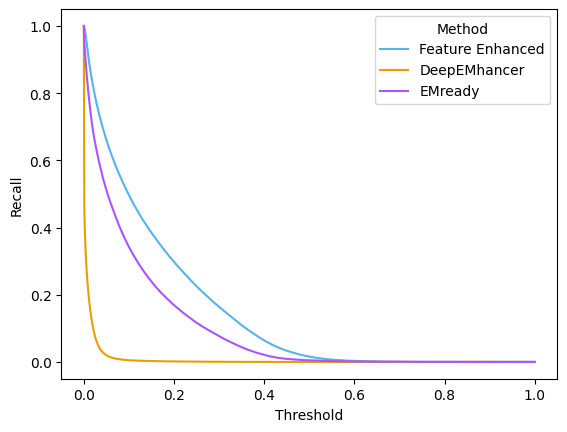

In [11]:
palette = {"Feature Enhanced": "#56b4e9", 
              "DeepEMhancer": "#e69f00", 
              "EMready": "#aa55ff"}
sns.lineplot(data=recall_data_0665, x='Threshold', y='Recall', hue='Method', palette=palette)

## Figure 6 i

In [12]:
# aurc_data_csv_path = "/home/abharadwaj1/papers/elife_paper/figure_information/outputs/recall_curve_area_DE_wide_diffmask.csv"
# aurc_data = pd.read_csv(aurc_data_csv_path)
# columns = ["EMDB ID", "Feature Enhanced", "DeepEMhancer", "EMready", "Membrane"]
# aurc_data.columns = columns
# # convert to long form 
# aurc_data_long = pd.melt(aurc_data, id_vars=['EMDB ID'], value_vars=['Feature Enhanced', 'DeepEMhancer', 'EMready'], var_name='Method', value_name='AURC')

aurc_data_save_path = os.path.join(PLOT_DATA_STORE_PATH, "aurc_data_all.csv")
# aurc_data_long.to_csv(aurc_data_save_path, index=True)

aurc_data_long = pd.read_csv(aurc_data_save_path)



<Axes: xlabel='Method', ylabel='AURC'>

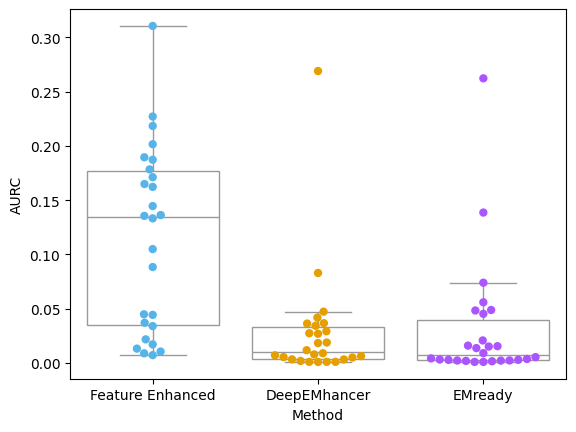

In [13]:
sns.boxplot(data=aurc_data_long, x='Method', y='AURC', color="white", showfliers=False)
sns.swarmplot(data=aurc_data_long, x='Method', y='AURC', hue='Method', palette=palette, dodge=False, size=6)


In [14]:
# run permutation tests to compute the significance of the differences between the methods
from scipy.stats import permutation_test

# test between feature enhanced and deepemhancer
def run_permutation_test(data1, data2, num_permutations=10000):
    def statistic(x, y):
        return np.mean(x) - np.mean(y)

    result = permutation_test((data1, data2), statistic, n_resamples=num_permutations, alternative='two-sided')
    # print 
    #print(f"pvalue: {result.pvalue}, statistic: {result.statistic} significance: {result.pvalue < 0.05}")
    return result

results = {}

fe_area = aurc_data_long[aurc_data_long["Method"] == "Feature Enhanced"]["AURC"]
deepemhancer_area = aurc_data_long[aurc_data_long["Method"] == "DeepEMhancer"]["AURC"]
emready_area = aurc_data_long[aurc_data_long["Method"] == "EMready"]["AURC"]


fe_deepemhancer = run_permutation_test(fe_area, deepemhancer_area)
fe_emready = run_permutation_test(fe_area, emready_area)
deepEMhancer_EMready = run_permutation_test(deepemhancer_area, emready_area)

print("Feature Enhanced vs DeepEMhancer", fe_deepemhancer.pvalue)
print("Feature Enhanced vs EMready", fe_emready.pvalue)
print("DeepEMhancer vs EMready", deepEMhancer_EMready.pvalue)



Feature Enhanced vs DeepEMhancer 0.00019998000199980003
Feature Enhanced vs EMready 0.0005999400059994001
DeepEMhancer vs EMready 0.8737126287371263
